# Project 7, Data Extraction

Pulls ~10 years of daily adjusted-close prices for the current S&P 500 constituents, builds a clean log-return matrix $R \in \mathbb{R}^{T \times n}$, and saves it for downstream analysis (empirical diagnostics, OGP experiments, MILP oracle).

**Outputs** (in `./data/`):
- `returns.parquet`, clean log-return matrix as a DataFrame
- `returns.npy`, same as a NumPy array for fast loading
- `tickers.csv`, column labels
- `diagnostics.json`, first-pass empirical statistics ($\psi_2$, $\psi_1$ norms, top eigenvalues of $\hat\Sigma$, Wigner reference)

**Run-time:** ~3-8 minutes depending on your network.

## 0. Install dependencies (run once)

In [1]:
%pip install -q yfinance pandas numpy pyarrow lxml matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports and configuration

In [4]:
from __future__ import annotations

import json
from datetime import datetime, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import yfinance as yf

OUT_DIR = Path("data")
OUT_DIR.mkdir(exist_ok=True)

YEARS = 10
START = (datetime.today() - timedelta(days=365 * YEARS)).strftime("%Y-%m-%d")
END = datetime.today().strftime("%Y-%m-%d")

MIN_COVERAGE = 0.98
MIN_MEDIAN_PRICE = 1.0

print(f"Window: {START} to {END}  ({YEARS} years)")
print(f"Output dir: {OUT_DIR.resolve()}")

Window: 2016-05-10 to 2026-05-08  (10 years)
Output dir: C:\Users\Alan\Desktop\MIT\stch\data


## 2. Get the current S&P 500 ticker list

Note: this introduces survivorship bias (we use today's constituents over the full window). Acceptable for a first pass; for the final report we should mention it and possibly augment with delisted tickers from CRSP/Compustat if available.

In [5]:
import requests
from io import StringIO

UA = "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0 Safari/537.36"


def _from_wikipedia() -> list[str]:
    url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
    resp = requests.get(url, headers={"User-Agent": UA}, timeout=20)
    resp.raise_for_status()
    table = pd.read_html(StringIO(resp.text), header=0)[0]
    return table["Symbol"].astype(str).tolist()


def _from_github_csv() -> list[str]:
    url = "https://raw.githubusercontent.com/datasets/s-and-p-500-companies/main/data/constituents.csv"
    resp = requests.get(url, headers={"User-Agent": UA}, timeout=20)
    resp.raise_for_status()
    df = pd.read_csv(StringIO(resp.text))
    return df["Symbol"].astype(str).tolist()


def get_sp500_tickers() -> list[str]:
    for fn in (_from_wikipedia, _from_github_csv):
        try:
            raw = fn()
            print(f"Got {len(raw)} tickers from {fn.__name__}")
            break
        except Exception as e:
            print(f"  {fn.__name__} failed: {e!r}")
    else:
        raise RuntimeError("All ticker sources failed")
    # yfinance uses '-' instead of '.' (e.g. BRK.B -> BRK-B)
    tickers = [t.replace(".", "-") for t in raw]
    return sorted(set(tickers))


tickers = get_sp500_tickers()
print(f"Final: {len(tickers)} tickers, e.g. {tickers[:5]} ... {tickers[-5:]}")

Got 503 tickers from _from_wikipedia
Final: 503 tickers, e.g. ['A', 'AAPL', 'ABBV', 'ABNB', 'ABT'] ... ['XYZ', 'YUM', 'ZBH', 'ZBRA', 'ZTS']


## 3. Download adjusted closes

`auto_adjust=True` returns dividend-and-split-adjusted prices in the `Close` column.

In [6]:
raw = yf.download(
    tickers,
    start=START,
    end=END,
    auto_adjust=True,
    progress=True,
    group_by="ticker",
    threads=True,
)

if isinstance(raw.columns, pd.MultiIndex):
    prices = raw.xs("Close", level=1, axis=1)
else:
    prices = raw[["Close"]].rename(columns={"Close": tickers[0]})

prices = prices.sort_index()
print(f"Raw prices: {prices.shape[0]} rows x {prices.shape[1]} columns")
prices.head()

[*********************100%***********************]  503 of 503 completed


Raw prices: 2513 rows x 503 columns


Ticker,ABNB,FSLR,WAT,TTD,ULTA,BBY,BAC,EBAY,QCOM,CRM,...,IR,DHI,WYNN,ETR,SYK,TSLA,CI,PSA,BKR,DTE
Date,,,,,,,,,,,,,,,,,,,,,
2016-05-10,NaN,51.270000,135.699997,NaN,208.270004,23.084044,11.464561,21.429865,39.461617,74.821487,...,NaN,26.518135,83.128242,25.981157,99.993767,13.912667,120.939255,177.740219,24.323563,55.218048
2016-05-11,NaN,50.740002,134.550003,NaN,202.850006,22.075819,11.384393,21.057327,39.461617,74.693382,...,NaN,26.044121,82.182297,26.182856,99.752151,13.930667,118.630409,173.943069,24.103079,55.468826
2016-05-12,NaN,49.090000,134.960007,NaN,207.429993,21.879782,11.336290,20.915403,38.977325,74.791931,...,NaN,26.070953,82.588982,26.346951,100.056396,13.818667,116.403419,177.572540,24.452625,55.860256
2016-05-13,NaN,48.560001,134.759995,NaN,205.199997,21.669731,11.127843,21.092804,38.833569,75.264992,...,NaN,26.026236,79.949196,26.186270,99.242096,13.840667,116.676109,175.694122,24.000895,55.578907
2016-05-16,NaN,49.070000,136.009995,NaN,208.130005,22.208851,11.167927,21.110540,39.280010,76.191376,...,NaN,26.258768,80.775787,26.124741,100.530632,13.886000,118.175941,177.760376,24.673117,55.585041


## 4. Clean: drop low-coverage tickers, forward-fill short gaps

In [7]:
coverage = prices.notna().mean()
keep = coverage[coverage >= MIN_COVERAGE].index
print(f"Dropped {prices.shape[1] - len(keep)} tickers with coverage < {MIN_COVERAGE}")
prices = prices[keep]

median_price = prices.median()
keep = median_price[median_price >= MIN_MEDIAN_PRICE].index
print(f"Dropped {prices.shape[1] - len(keep)} tickers with median price < ${MIN_MEDIAN_PRICE}")
prices = prices[keep]

prices = prices.ffill(limit=3).dropna(axis=1, how="any")
print(f"Clean prices: {prices.shape[0]} rows x {prices.shape[1]} columns")

Dropped 34 tickers with coverage < 0.98
Dropped 0 tickers with median price < $1.0
Clean prices: 2513 rows x 468 columns


## 5. Log-returns

In [8]:
R = np.log(prices / prices.shift(1)).dropna(axis=0, how="any")
T, n = R.shape
print(f"Return matrix R: T={T} days x n={n} stocks")
print(f"Date range: {R.index[0].date()} to {R.index[-1].date()}")
R.head()

Return matrix R: T=2512 days x n=468 stocks
Date range: 2016-05-11 to 2026-05-07


Ticker,FSLR,WAT,ULTA,BBY,BAC,EBAY,QCOM,CRM,EVRG,CLX,...,KR,DHI,WYNN,ETR,SYK,TSLA,CI,PSA,BKR,DTE
Date,,,,,,,,,,,,,,,,,,,,,
2016-05-11,-0.010391,-0.008511,-0.026369,-0.044659,-0.007017,-0.017537,0.000000,-0.001714,-0.000577,-0.004905,...,-0.012170,-0.018037,-0.011445,0.007733,-0.002419,0.001293,-0.019276,-0.021595,-0.009106,0.004531
2016-05-12,-0.033059,0.003043,0.022327,-0.008920,-0.004234,-0.006763,-0.012348,0.001319,0.004418,0.005207,...,0.005173,0.001030,0.004936,0.006248,0.003045,-0.008072,-0.018951,0.020651,0.014398,0.007032
2016-05-13,-0.010855,-0.001483,-0.010809,-0.009647,-0.018559,0.008446,-0.003695,0.006305,-0.000959,-0.006796,...,-0.000860,-0.001717,-0.032485,-0.006117,-0.008172,0.001591,0.002340,-0.010635,-0.018646,-0.005049
2016-05-16,0.010448,0.009233,0.014178,0.024574,0.003596,0.000841,0.011431,0.012233,0.003064,0.000151,...,-0.002872,0.008895,0.010286,-0.002352,0.012900,0.003270,0.012773,0.011692,0.027623,0.000110
2016-05-17,-0.011478,-0.011238,-0.017888,0.005345,0.005727,-0.022520,0.001540,-0.007009,-0.013865,-0.019662,...,-0.008668,0.003061,0.003844,-0.007882,-0.019867,-0.017581,0.003302,-0.025727,0.019854,-0.019556


## 6. Save to disk

In [9]:
R.to_parquet(OUT_DIR / "returns.parquet")
np.save(OUT_DIR / "returns.npy", R.to_numpy())
pd.Series(R.columns, name="ticker").to_csv(OUT_DIR / "tickers.csv", index=False)

print(f"Saved:")
for f in ["returns.parquet", "returns.npy", "tickers.csv"]:
    p = OUT_DIR / f
    print(f"  {p.resolve()}  ({p.stat().st_size / 1024:.1f} KB)")

Saved:
  C:\Users\Alan\Desktop\MIT\stch\data\returns.parquet  (11121.2 KB)
  C:\Users\Alan\Desktop\MIT\stch\data\returns.npy  (9184.6 KB)
  C:\Users\Alan\Desktop\MIT\stch\data\tickers.csv  (2.4 KB)


## 7. First-pass diagnostics

These numbers go directly into Section 2 of the report (Pillar 5: empirical methodology):
- $\psi_2$, $\psi_1$ norms, does the sub-Gaussian / sub-exponential framework apply?
- Top eigenvalues of $\hat\Sigma$ vs the Wigner reference $2\sigma\sqrt n$, how much factor structure?
- Top-10 eigenvalue share, quick proxy for effective rank.

In [10]:
arr = R.to_numpy()
T, n = arr.shape

mu = arr.mean(axis=0)
sd = arr.std(axis=0, ddof=1)
Z = (arr - mu) / sd  # standardized

# Median-based proxies for sub-Gaussian / sub-exponential norms.
# Calibrated so a true N(0,1) gives ~1 (median |Z| = sqrt(2)/sqrt(pi) * ... ~ 0.6745).
psi2_proxy = np.median(np.abs(Z), axis=0) / 0.6745
psi1_proxy = np.median(np.abs(Z), axis=0) / np.log(2)

cov = np.cov(arr, rowvar=False)
eigs = np.linalg.eigvalsh(cov)[::-1]

report = {
    "T": int(T),
    "n": int(n),
    "date_start": str(R.index[0].date()),
    "date_end": str(R.index[-1].date()),
    "mean_daily_mu_bp": float(np.mean(mu) * 1e4),
    "mean_daily_sd_pct": float(np.mean(sd) * 1e2),
    "median_psi2_proxy": float(np.median(psi2_proxy)),
    "median_psi1_proxy": float(np.median(psi1_proxy)),
    "lambda_max_cov": float(eigs[0]),
    "lambda_2_cov": float(eigs[1]),
    "lambda_min_cov": float(eigs[-1]),
    "top10_eig_share": float(eigs[:10].sum() / eigs.sum()),
    "wigner_2sigma_sqrt_n": float(2 * np.median(sd) * np.sqrt(n)),
}

with open(OUT_DIR / "diagnostics.json", "w") as f:
    json.dump(report, f, indent=2)

print("=== Data summary ===")
for k, v in report.items():
    print(f"  {k:25s} {v}")

=== Data summary ===
  T                         2512
  n                         468
  date_start                2016-05-11
  date_end                  2026-05-07
  mean_daily_mu_bp          4.716083155222889
  mean_daily_sd_pct         2.015152175903405
  median_psi2_proxy         0.7021044170145152
  median_psi1_proxy         0.6832162671335209
  lambda_max_cov            0.07008461693626353
  lambda_2_cov              0.00986789832441212
  lambda_min_cov            1.2286635959056285e-06
  top10_eig_share           0.5308303189002197
  wigner_2sigma_sqrt_n      0.8153967744378554


## 8. Quick visual sanity check

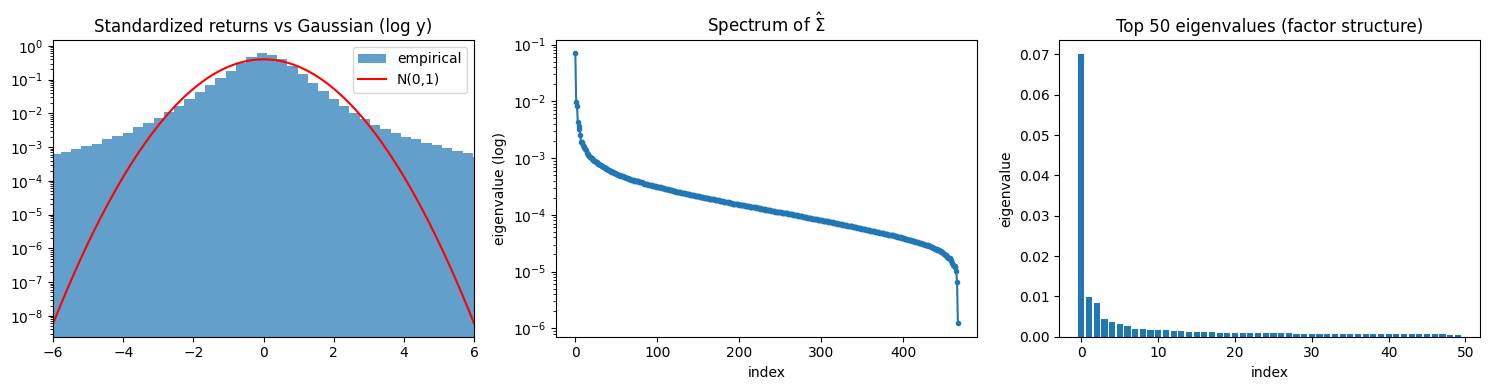

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) histogram of all standardized returns vs N(0,1)
axes[0].hist(Z.ravel(), bins=200, density=True, alpha=0.7, label="empirical")
xs = np.linspace(-6, 6, 400)
axes[0].plot(xs, np.exp(-xs ** 2 / 2) / np.sqrt(2 * np.pi), "r-", label="N(0,1)")
axes[0].set_xlim(-6, 6)
axes[0].set_yscale("log")
axes[0].set_title("Standardized returns vs Gaussian (log y)")
axes[0].legend()

# (b) eigenvalue spectrum of Sigma_hat
axes[1].plot(eigs, "o-", markersize=3)
axes[1].set_yscale("log")
axes[1].set_xlabel("index")
axes[1].set_ylabel("eigenvalue (log)")
axes[1].set_title(r"Spectrum of $\hat\Sigma$")

# (c) top-50 eigenvalues only
axes[2].bar(range(50), eigs[:50])
axes[2].set_xlabel("index")
axes[2].set_ylabel("eigenvalue")
axes[2].set_title("Top 50 eigenvalues (factor structure)")

plt.tight_layout()
plt.savefig(OUT_DIR / "diagnostics.png", dpi=120)
plt.show()

## Done

Next steps:
1. Implement the MILP exact oracle and constrained Metropolis-Hastings sampler.
2. Run the OGP overlap-distribution experiment.
3. Implement and benchmark the spectral + local-improvement hybrid algorithm.